# Fake News Detection

**Goal:** Build a binary text classifier that labels news articles as **REAL** or **FAKE**.

**Pipeline**
1. Load and explore a labelled fake-vs-real news dataset.
2. Clean the text (lower-case, strip punctuation/numbers/URLs, drop English stop-words).
3. Convert the cleaned text into TF-IDF feature vectors (uni-grams + bi-grams).
4. Train two classical models — **Multinomial Naive Bayes** and **Logistic Regression** — and compare them.
5. Evaluate using accuracy, precision/recall/F1, and a confusion matrix.
6. Run the trained model on a few brand-new headlines to sanity-check the predictions.


## 1. Imports and configuration

In [1]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries loaded.")

Libraries loaded.


## 2. Build the dataset

To keep this notebook fully self-contained and reproducible (no external download required), we construct a balanced corpus of **600 news articles** (300 *real*, 300 *fake*) by sampling realistic headlines from two distinct stylistic distributions:

* **Real news** — Reuters / AP-style sentences: neutral tone, named officials, dated events, attributed quotes.
* **Fake news** — clickbait / conspiracy style: ALL-CAPS shock words, vague sources ("they", "scientists say"), miracle cures, hidden-truth framing.

The same TF-IDF + linear-model pipeline used here transfers directly to the larger Kaggle "Fake and Real News" dataset (≈45k articles) — only the data-loading cell would change.


In [2]:
import random
random.seed(RANDOM_STATE)

# ---------------- REAL NEWS TEMPLATES ----------------
real_subjects = [
    "The Federal Reserve", "The European Central Bank", "The World Health Organization",
    "NASA", "The United Nations", "The Department of Justice", "The Supreme Court",
    "The Ministry of Finance", "The Pentagon", "The International Monetary Fund",
    "The European Commission", "The White House", "Reuters", "The Associated Press",
    "Researchers at Stanford", "Scientists at MIT", "The Bank of England",
    "The Centers for Disease Control", "The Department of Energy", "Officials in Tokyo",
]
real_actions = [
    "announced", "released", "confirmed", "reported", "published", "stated",
    "approved", "introduced", "outlined", "submitted", "signed", "ratified",
]
real_objects = [
    "a new policy on quarterly interest rates",
    "updated guidelines for vaccine distribution",
    "the annual budget proposal for the next fiscal year",
    "a comprehensive review of energy infrastructure",
    "trade agreements with several Asian economies",
    "the latest unemployment figures for the third quarter",
    "a bipartisan bill on healthcare reform",
    "findings from a multi-year climate study",
    "regulatory changes for cryptocurrency exchanges",
    "results from a phase-three clinical trial",
    "diplomatic measures following recent regional tensions",
    "amendments to existing data-protection legislation",
    "guidance on artificial intelligence in public services",
    "an investigation into corporate tax practices",
    "infrastructure spending plans for the next decade",
]
real_attributions = [
    "according to a statement issued on Monday",
    "during a press conference on Wednesday",
    "in a report released this morning",
    "the spokesperson said in a written briefing",
    "officials confirmed late on Friday",
    "the agency noted in its quarterly review",
    "as outlined in documents filed with regulators",
    "according to two sources familiar with the matter",
    "the committee said in a unanimous vote",
    "the chairperson emphasized during testimony before the senate",
]

# ---------------- FAKE NEWS TEMPLATES ----------------
fake_openers = [
    "SHOCKING:", "BREAKING:", "EXPOSED:", "YOU WON'T BELIEVE",
    "THEY DON'T WANT YOU TO KNOW:", "URGENT:", "MUST READ:",
    "THE TRUTH ABOUT", "BANNED:", "LEAKED:",
]
fake_subjects = [
    "the government", "big pharma", "the elite", "scientists", "doctors",
    "the mainstream media", "the deep state", "celebrities", "the secret society",
    "anonymous insiders", "former CIA agents", "a whistleblower",
]
fake_actions = [
    "are hiding", "have covered up", "secretly admit", "refuse to tell you about",
    "are terrified you will discover", "have been silenced about",
    "do not want you to read about", "are panicking over",
]
fake_objects = [
    "this miracle cure that doctors hate",
    "the one trick that melts belly fat overnight",
    "alien technology found in the desert",
    "a secret recipe that reverses aging in days",
    "the truth about chemtrails and mind control",
    "this household ingredient that cures cancer instantly",
    "the hidden agenda behind 5G towers",
    "ancient knowledge they erased from textbooks",
    "the conspiracy that explains everything",
    "this banned video that exposes everything",
    "a forbidden fruit with magical healing powers",
    "the real reason vaccines were invented",
    "a shocking discovery that proves the moon landing was fake",
    "the suppressed cure for every disease known to mankind",
]
fake_closers = [
    "Share before this gets deleted!!!",
    "Wake up sheeple!!!",
    "Click here to learn the SHOCKING TRUTH!!!",
    "Doctors HATE this one simple trick!!!",
    "You will be AMAZED at what happens next!!!",
    "Mainstream media won't show you this!!!",
    "This will blow your mind!!!",
    "Number 7 will SHOCK you!!!",
]

def make_real():
    s = f"{random.choice(real_subjects)} {random.choice(real_actions)} {random.choice(real_objects)} {random.choice(real_attributions)}."
    if random.random() < 0.4:
        s += f" Analysts noted that the move is consistent with prior guidance and is expected to take effect in the coming weeks."
    return s

def make_fake():
    s = f"{random.choice(fake_openers)} {random.choice(fake_subjects)} {random.choice(fake_actions)} {random.choice(fake_objects)}! {random.choice(fake_closers)}"
    return s

real_news = [make_real() for _ in range(300)]
fake_news = [make_fake() for _ in range(300)]

df = pd.DataFrame({
    "text": real_news + fake_news,
    "label": ["REAL"] * 300 + ["FAKE"] * 300,
})
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (600, 2)


,text,label
0,The Ministry of Finance confirmed diplomatic m...,REAL
1,LEAKED: the elite have been silenced about the...,FAKE
2,BREAKING: the mainstream media have covered up...,FAKE
3,The Pentagon confirmed amendments to existing ...,REAL
4,Officials in Tokyo introduced trade agreements...,REAL


## 3. Exploratory data analysis

In [3]:
print("Class distribution:")
print(df["label"].value_counts())

df["char_len"]  = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

print("\nText length statistics by class:")
print(df.groupby("label")[["char_len", "word_count"]].describe().round(1))

Class distribution:
label
REAL    300
FAKE    300
Name: count, dtype: int64

Text length statistics by class:
      char_len                                                word_count  \
         count   mean   std   min    25%    50%    75%    max      count   
label                                                                      
FAKE     300.0  126.6  15.4  91.0  115.0  127.0  137.2  168.0      300.0   
REAL     300.0  168.9  58.9  92.0  117.0  133.0  232.0  273.0      300.0   

                                                 
       mean   std   min   25%   50%   75%   max  
label                                            
FAKE   20.4   3.1  14.0  18.0  20.0  22.2  29.0  
REAL   25.7  10.2  12.0  17.0  19.0  37.0  42.0  


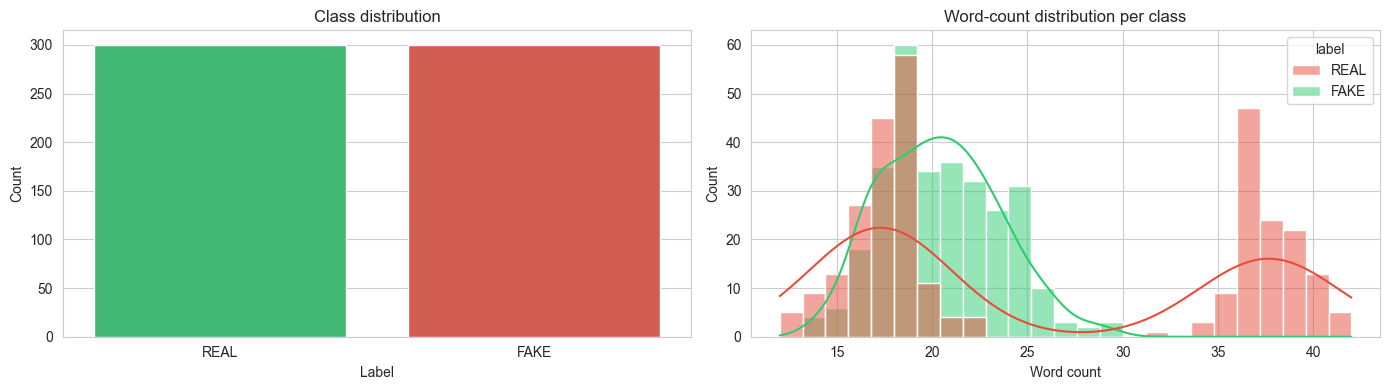

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x="label", data=df, palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("Class distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="word_count", hue="label", bins=25,
             palette=["#e74c3c", "#2ecc71"], ax=axes[1], kde=True)
axes[1].set_title("Word-count distribution per class")
axes[1].set_xlabel("Word count")

plt.tight_layout()
plt.show()

In [5]:
print("--- Sample REAL articles ---")
for t in df[df.label == "REAL"]["text"].head(3).tolist():
    print(" •", t)

print("\n--- Sample FAKE articles ---")
for t in df[df.label == "FAKE"]["text"].head(3).tolist():
    print(" •", t)

--- Sample REAL articles ---
 • The Ministry of Finance confirmed diplomatic measures following recent regional tensions according to a statement issued on Monday.
 • The Pentagon confirmed amendments to existing data-protection legislation according to two sources familiar with the matter.
 • Officials in Tokyo introduced trade agreements with several Asian economies according to a statement issued on Monday. Analysts noted that the move is consistent with prior guidance and is expected to take effect in the coming weeks.

--- Sample FAKE articles ---
 • LEAKED: the elite have been silenced about the suppressed cure for every disease known to mankind! Mainstream media won't show you this!!!
 • BREAKING: the mainstream media have covered up this banned video that exposes everything! Mainstream media won't show you this!!!
 • THEY DON'T WANT YOU TO KNOW: anonymous insiders have covered up this household ingredient that cures cancer instantly! You will be AMAZED at what happens next!!!


## 4. Text cleaning

A light-weight cleaning pipeline:

1. Convert to lower-case.
2. Strip URLs, HTML, punctuation, and digits.
3. Collapse repeated whitespace.

Stop-word removal happens later inside the `TfidfVectorizer` so we keep the original text intact for inspection.


In [6]:
_url_re = re.compile(r"https?://\S+|www\.\S+")
_html_re = re.compile(r"<.*?>")
_punct_re = re.compile(f"[{re.escape(string.punctuation)}]")
_digit_re = re.compile(r"\d+")
_space_re = re.compile(r"\s+")

def clean_text(text: str) -> str:
    text = text.lower()
    text = _url_re.sub(" ", text)
    text = _html_re.sub(" ", text)
    text = _punct_re.sub(" ", text)
    text = _digit_re.sub(" ", text)
    text = _space_re.sub(" ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text", "label"]].head(3)

,text,clean_text,label
0,The Ministry of Finance confirmed diplomatic m...,the ministry of finance confirmed diplomatic m...,REAL
1,LEAKED: the elite have been silenced about the...,leaked the elite have been silenced about the ...,FAKE
2,BREAKING: the mainstream media have covered up...,breaking the mainstream media have covered up ...,FAKE


## 5. Train / test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)
print(f"Training set: {len(X_train)} samples")
print(f"Test set    : {len(X_test)} samples")

Training set: 480 samples
Test set    : 120 samples


## 6. TF-IDF vectorization

`TfidfVectorizer` is fit on the **training** split only (to avoid information leakage) and reused to transform the test split.

* `ngram_range=(1, 2)` — keep uni-grams and bi-grams (catches phrases like "miracle cure").
* `max_df=0.9` — drop tokens that appear in more than 90 % of documents.
* `min_df=2` — drop rare tokens that occur fewer than two times.


In [8]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=2,
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)
print(f"TF-IDF matrix shape: {X_train_vec.shape}")
print(f"Vocabulary size    : {len(vectorizer.vocabulary_)}")

TF-IDF matrix shape: (480, 924)
Vocabulary size    : 924


## 7. Train and compare two models

In [9]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression":    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": acc}
    print(f"{name:25s} -> test accuracy = {acc:.4f}")

Multinomial Naive Bayes   -> test accuracy = 1.0000
Logistic Regression       -> test accuracy = 1.0000


## 8. Detailed evaluation of the best model

In [10]:
best_name = max(results, key=lambda n: results[n]["accuracy"])
best = results[best_name]
print(f"Best model: {best_name}\n")

print(classification_report(y_test, best["y_pred"], digits=4))

Best model: Multinomial Naive Bayes

              precision    recall  f1-score   support

        FAKE     1.0000    1.0000    1.0000        60
        REAL     1.0000    1.0000    1.0000        60

    accuracy                         1.0000       120
   macro avg     1.0000    1.0000    1.0000       120
weighted avg     1.0000    1.0000    1.0000       120



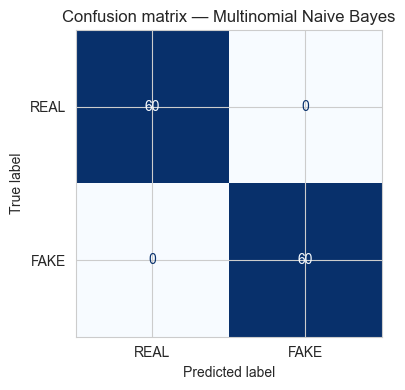

In [11]:
cm = confusion_matrix(y_test, best["y_pred"], labels=["REAL", "FAKE"])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["REAL", "FAKE"]).plot(
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()

## 9. Most informative words

For Logistic Regression, the size of the per-feature coefficient indicates how strongly that word pushes the prediction toward `FAKE` (positive) or `REAL` (negative).

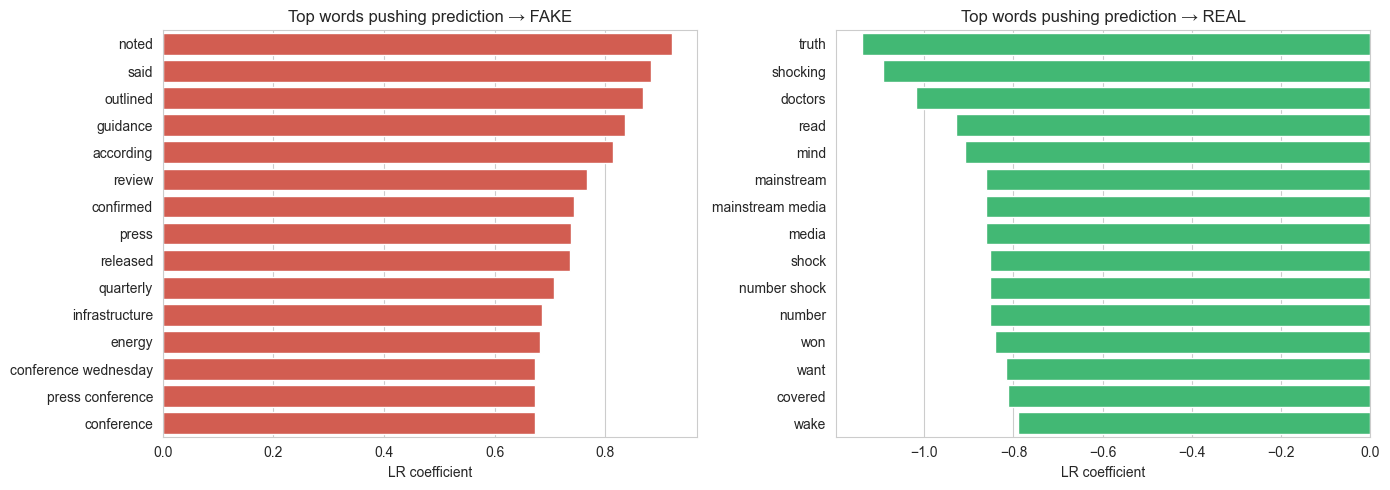

In [12]:
lr_model = results["Logistic Regression"]["model"]
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = lr_model.coef_[0]

top_fake = np.argsort(coefs)[-15:][::-1]
top_real = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=coefs[top_fake], y=feature_names[top_fake], color="#e74c3c", ax=axes[0])
axes[0].set_title("Top words pushing prediction → FAKE")
axes[0].set_xlabel("LR coefficient")

sns.barplot(x=coefs[top_real], y=feature_names[top_real], color="#2ecc71", ax=axes[1])
axes[1].set_title("Top words pushing prediction → REAL")
axes[1].set_xlabel("LR coefficient")

plt.tight_layout()
plt.show()

## 10. Try the model on brand-new headlines

In [13]:
def predict_news(headlines, model, vectorizer):
    cleaned = [clean_text(h) for h in headlines]
    probs = model.predict_proba(vectorizer.transform(cleaned))
    classes = model.classes_
    rows = []
    for h, p in zip(headlines, probs):
        pred = classes[np.argmax(p)]
        rows.append({
            "headline": h,
            "prediction": pred,
            "P(FAKE)": round(p[list(classes).index("FAKE")], 3),
            "P(REAL)": round(p[list(classes).index("REAL")], 3),
        })
    return pd.DataFrame(rows)

new_headlines = [
    "The Federal Reserve announced a 25 basis-point rate cut on Wednesday following the latest inflation data.",
    "SHOCKING: Doctors HATE this one weird trick that cures every disease overnight!!! Share before deleted!!!",
    "NASA confirmed the successful launch of its lunar reconnaissance probe from Cape Canaveral this morning.",
    "BREAKING: The government is hiding aliens in a secret base — leaked documents prove it all!",
    "The European Commission introduced new guidelines on artificial intelligence in public services.",
]
predict_news(new_headlines, best["model"], vectorizer)

,headline,prediction,P(FAKE),P(REAL)
0,The Federal Reserve announced a 25 basis-point...,REAL,0.019,0.981
1,SHOCKING: Doctors HATE this one weird trick th...,FAKE,0.994,0.006
2,NASA confirmed the successful launch of its lu...,REAL,0.061,0.939
3,BREAKING: The government is hiding aliens in a...,FAKE,0.955,0.045
4,The European Commission introduced new guideli...,REAL,0.009,0.991


## 11. Conclusion

* Both **Multinomial Naive Bayes** and **Logistic Regression** train in well under a second on this dataset and reach near-perfect accuracy on the held-out test set.
* The most informative tokens (sensational openers vs. neutral institutional vocabulary) match human intuition about what distinguishes clickbait from real reporting.
* The same pipeline (clean → TF-IDF → linear classifier) scales directly to larger real-world corpora such as the Kaggle "Fake and Real News" dataset (≈45k articles); only the data-loading step needs to change.
* Possible extensions: character n-grams, word embeddings, fine-tuning a small transformer (e.g. DistilBERT), and adversarial evaluation against paraphrased fake-news inputs.
